In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train = X_train/255
X_test = X_test/255

- **Conv2D(filters,kernel_size,strides)**
> - `filters`: kernel의 수
> - `kernel_size`: kernel의 크기 (일반적으로 (3,3))
> - `strides`: kernel의 이동 보폭 (default (1,1))
> - `activation`: activation function (일반적으로 relu)
- **MaxPooling2D(pool_size,strides)**
> - `pool_size`: pool의 크기 (default (2,2))
> - `strides`: pool의 이동 보폭 (default None, pool_size와 동일)

In [5]:
cnn_model = Sequential([
    # -- input layer: 이미지를 입력으로 하여, Conv2D에 전달할 경우 (가로,세로,채널)의 형태로 shape을 지졍함
    #    channel 1: gray(흑백) image, channel 3: rgb/hsv(컬러) image
    #    mnist image의 경우, (28,28)이 아닌 채널까지 포함하여 (28,28,1)로 지정함
    Input(shape=(28,28,1)),
    # -- 특징 추출부
    Conv2D(filters=16,kernel_size=(3,3),strides=(1,1),activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)),
    # 이미지를 1d로 변경
    Flatten(),
    # -- 분류부
    Dense(units=256,activation='relu'),
    # output layer node의 수 = class의 수,
    # 분류(classification)의 경우, 일반적으로 activation function은 softmax 사용
    Dense(units=10,activation='softmax')
])

In [ ]:
cnn_model.summary()

In [9]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [10]:
train_result = cnn_model.fit(X_train,y_train,validation_split=0.3,epochs=15,batch_size=1024)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 357ms/step - acc: 0.6998 - loss: 1.1641 - val_acc: 0.9142 - val_loss: 0.2876
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - acc: 0.9181 - loss: 0.2782 - val_acc: 0.9382 - val_loss: 0.2119
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 367ms/step - acc: 0.9459 - loss: 0.1864 - val_acc: 0.9537 - val_loss: 0.1654
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - acc: 0.9533 - loss: 0.1562 - val_acc: 0.9578 - val_loss: 0.1419
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 346ms/step - acc: 0.9652 - loss: 0.1219 - val_acc: 0.9665 - val_loss: 0.1160
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 348ms/step - acc: 0.9740 - loss: 0.0942 - val_acc: 0.9710 - val_loss: 0.0988
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 344ms/step - acc: 0.9795 - loss: 0.0741 - val_acc: 0.9716 - val_loss: 0.0950
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 347ms/step - acc: 0.9786 - loss: 0.0759 - val_acc: 0.9726 - val_loss: 0.0907
Epoch 9/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 340ms/

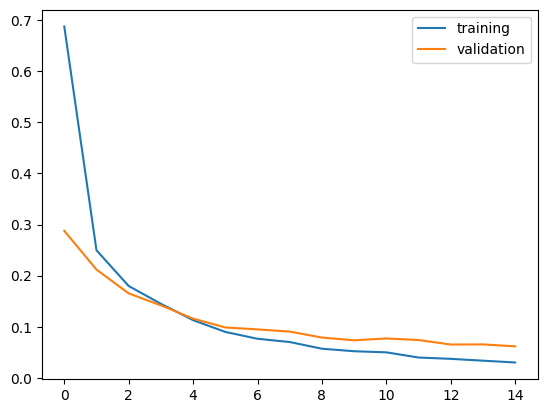

In [11]:
plt.plot(train_result.history['loss'],label='training')
plt.plot(train_result.history['val_loss'],label='validation')
plt.legend()

In [12]:
cnn_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9786 - loss: 0.0591


[0.04954973980784416, 0.9825000166893005]